In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
#Read the AirBnb Data
df = pd.read_csv('/content/Airbnb_Open_Data.csv', low_memory = False)

In [4]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,8.001449e+10,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,19-10-2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,5.233517e+10,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,21-05-2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,7.882924e+10,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,8.509833e+10,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,05-07-2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,9.203760e+10,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,19-11-2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70459 entries, 0 to 70458
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              70459 non-null  int64  
 1   NAME                            70251 non-null  object 
 2   host id                         70458 non-null  float64
 3   host_identity_verified          70241 non-null  object 
 4   host name                       70175 non-null  object 
 5   neighbourhood group             70429 non-null  object 
 6   neighbourhood                   70442 non-null  object 
 7   lat                             70450 non-null  float64
 8   long                            70450 non-null  float64
 9   country                         70135 non-null  object 
 10  country code                    70372 non-null  object 
 11  instant_bookable                70372 non-null  object 
 12  cancellation_policy             

In [6]:
df.duplicated().value_counts()

,count
False,70459


In [7]:
# Neighbourhood group was 'brookln' instead of 'Brooklyn'
df[df['neighbourhood group'] == 'brookln']

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
13,1008516,"Lovely Room 1, Garden, Best Area, Legal rental",2.680241e+10,verified,Darcy,brookln,South Slope,40.66829,-73.98779,United States,...,$116,4.0,167.0,24-06-2019,1.34,4.0,3.0,47.0,NaN,NaN


In [8]:
# Drop duplicate records
df.drop_duplicates(inplace=True)

# Drop house_rules and license columns with insufficient data (ignore if missing)
df.drop(['house_rules', 'license'], axis=1, inplace=True, errors='ignore')

# Remove dollar signs and commas in price and service fee columns if they exist
if 'price' in df.columns:
    df['price'] = df['price'].astype(str).str.replace('$', '', regex=False)
    df['price'] = df['price'].str.replace(',', '', regex=False)

if 'service fee' in df.columns:
    df['service fee'] = df['service fee'].astype(str).str.replace('$', '', regex=False)
    df['service fee'] = df['service fee'].str.replace(',', '', regex=False)

# Rename columns if they exist
rename_map = {}
if 'price' in df.columns:
    rename_map['price'] = 'price_$'
if 'service fee' in df.columns:
    rename_map['service fee'] = 'service_fee_$'

df.rename(columns=rename_map, inplace=True)

# Drop all records with missing values
df.dropna(inplace=True)

# Change all mismatched data types safely
if 'price_$' in df.columns:
    df['price_$'] = pd.to_numeric(df['price_$'], errors='coerce')
if 'service_fee_$' in df.columns:
    df['service_fee_$'] = pd.to_numeric(df['service_fee_$'], errors='coerce')

if 'id' in df.columns:
    df['id'] = df['id'].astype(str)
if 'host_id' in df.columns:
    df['host_id'] = df['host_id'].astype(str)
if 'last review' in df.columns:
    df['last review'] = pd.to_datetime(df['last review'], errors='coerce')
if 'Construction year' in df.columns:
    df['Construction year'] = pd.to_numeric(df['Construction year'], errors='coerce').astype('Int64')

# Correct spelling in neighbourhood group if it exists
if 'neighbourhood group' in df.columns:
    df.loc[df['neighbourhood group'].str.lower() == 'brookln', 'neighbourhood group'] = 'Brooklyn'

# Remove outliers in availability 365 if it exists
if 'availability 365' in df.columns:
    df = df[df['availability 365'] <= 500]

# Reset index after cleaning
df.reset_index(drop=True, inplace=True)


/tmp/ipython-input-3242064726.py:39: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['last review'] = pd.to_datetime(df['last review'], errors='coerce')


In [9]:
df.duplicated().value_counts()

,count
False,57820


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57820 entries, 0 to 57819
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              57820 non-null  object        
 1   NAME                            57820 non-null  object        
 2   host id                         57820 non-null  float64       
 3   host_identity_verified          57820 non-null  object        
 4   host name                       57820 non-null  object        
 5   neighbourhood group             57820 non-null  object        
 6   neighbourhood                   57820 non-null  object        
 7   lat                             57820 non-null  float64       
 8   long                            57820 non-null  float64       
 9   country                         57820 non-null  object        
 10  country code                    57820 non-null  object        
 11  in

In [11]:
# What are the different property types in the Dataset?
property_types = df['room type'].value_counts().to_frame()
property_types

,count
room type,
Entire home/apt,31499
Private room,25103
Shared room,1108
Hotel room,110


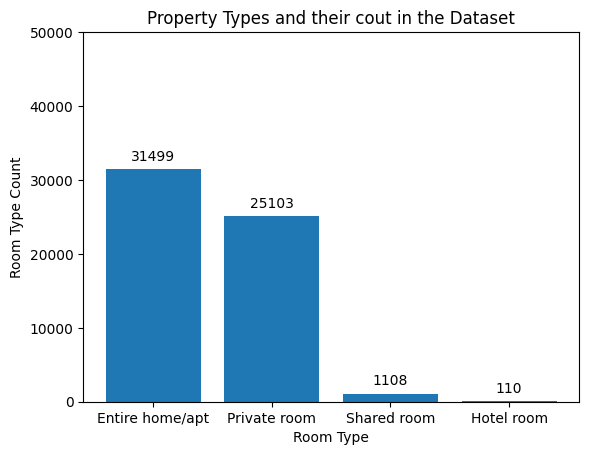

In [12]:
# Room type count plotted on a barchart
room_type_bar = plt.bar(property_types.index,property_types.loc[:,"count"] );
plt.bar_label(room_type_bar, labels = property_types.loc[:,"count"],padding = 4);
plt.ylim([0,50000]);
plt.xlabel('Room Type');
plt.ylabel('Room Type Count');
plt.title('Property Types and their cout in the Dataset');

In [13]:
hood_group = df['neighbourhood group'].value_counts().to_frame()
hood_group

,count
neighbourhood group,
Manhattan,23995
Brooklyn,23703
Queens,7926
Bronx,1634
Staten Island,562


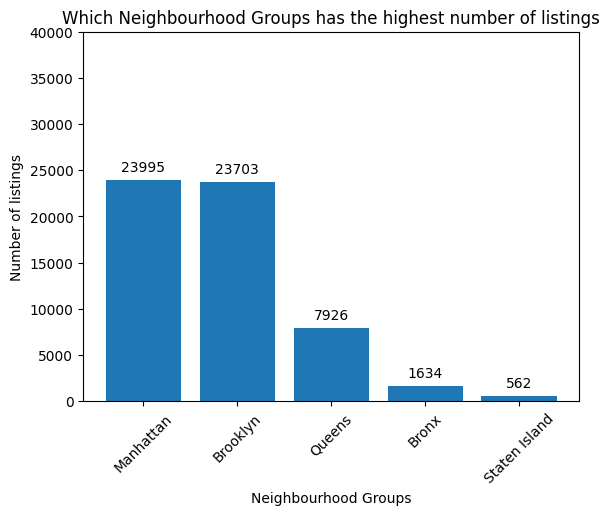

In [14]:
# Which neighbourhood group has the highest number of listings?
hood_group_bar = plt.bar(hood_group.index,hood_group.loc[:,"count"] );
plt.bar_label(hood_group_bar, labels = hood_group.loc[:,"count"],padding = 4);
plt.ylim([0,40000]);
plt.xlabel('Neighbourhood Groups');
plt.ylabel('Number of listings');
plt.xticks(rotation = 45);
plt.title('Which Neighbourhood Groups has the highest number of listings');

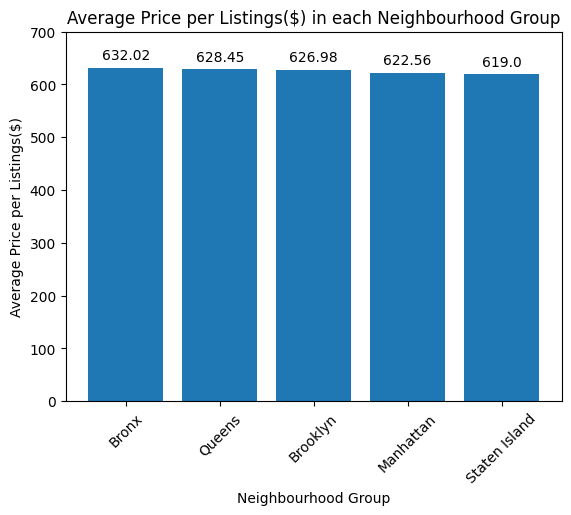

In [15]:
# Which Neighbourhoods group have the highest average prices for Airbnb listings?
avg_price = df.groupby('neighbourhood group')['price_$'].mean().sort_values(ascending=False).to_frame()
avg_price_bar = plt.bar(avg_price.index,avg_price.loc[:,"price_$"] );
plt.bar_label(avg_price_bar, labels = round(avg_price.loc[:,"price_$"],2),label_type = 'edge', padding = 4);
plt.ylim([0,700]);
plt.xlabel('Neighbourhood Group');
plt.ylabel('Average Price per Listings($)');
plt.xticks(rotation = 45);
plt.title('Average Price per Listings($) in each Neighbourhood Group');

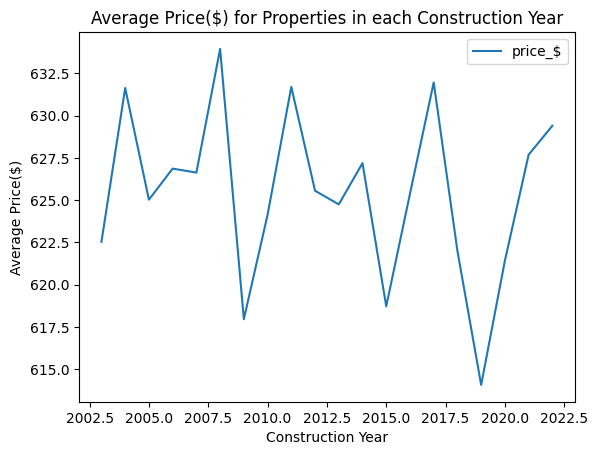

In [16]:
# Is there a relationship between the construction year of property and price?
df.groupby(df['Construction year'])['price_$'].mean().to_frame().plot();
plt.xlabel('Construction Year');
plt.ylabel('Average Price($)');
plt.title('Average Price($) for Properties in each Construction Year');

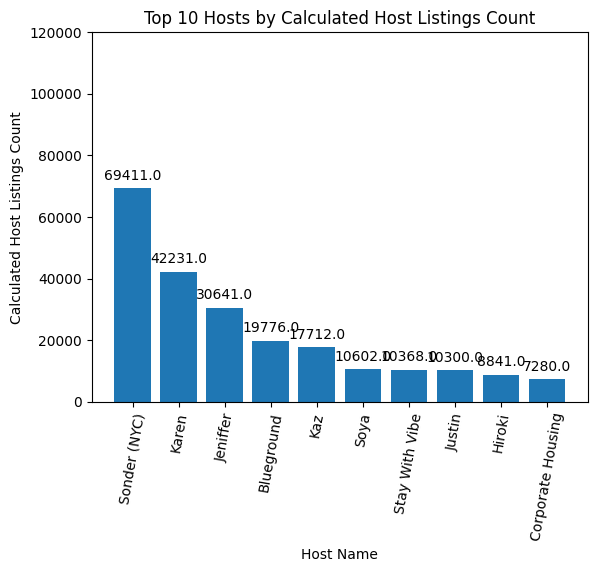

In [22]:
# Who are the top 10 hostss by calculated host listing count?
hosts = df.groupby('host name')['calculated host listings count'].sum().sort_values(ascending=False).nlargest(10).to_frame()
hosts_bar = plt.bar(hosts.index,hosts.loc[:,"calculated host listings count"] );
plt.bar_label(hosts_bar, labels = hosts.loc[:,"calculated host listings count"],label_type = 'edge', padding = 4);
plt.xlabel('Host Name');
plt.ylabel('Calculated Host Listings Count');
plt.xticks(rotation = 80);
plt.ylim([0,120000]);
plt.title('Top 10 Hosts by Calculated Host Listings Count');

In [23]:
# Are hosts with verified identities more likely to receive postive reviews?
review = df.groupby('host_identity_verified')['review rate number'].mean().sort_values(ascending = False).to_frame()
review

,review rate number
host_identity_verified,
unconfirmed,3.319487
verified,3.314688


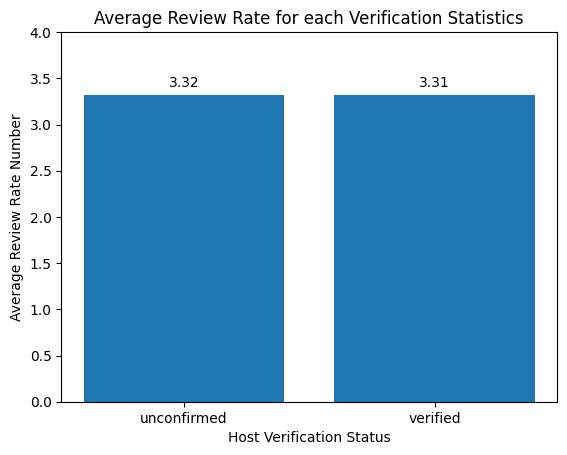

In [25]:
review_bar = plt.bar(review.index,review.loc[:,"review rate number"] );
plt.bar_label(review_bar, labels = round(review.loc[:,"review rate number"],2), padding = 4);
plt.ylim([0,4]);
plt.xlabel('Host Verification Status');
plt.ylabel('Average Review Rate Number');
plt.title('Average Review Rate for each Verification Statistics');

In [26]:
# Is there a correlation between the price of a listing and its service fee?
df['price_$'].corr(df['service_fee_$'])

np.float64(0.9999909416945248)

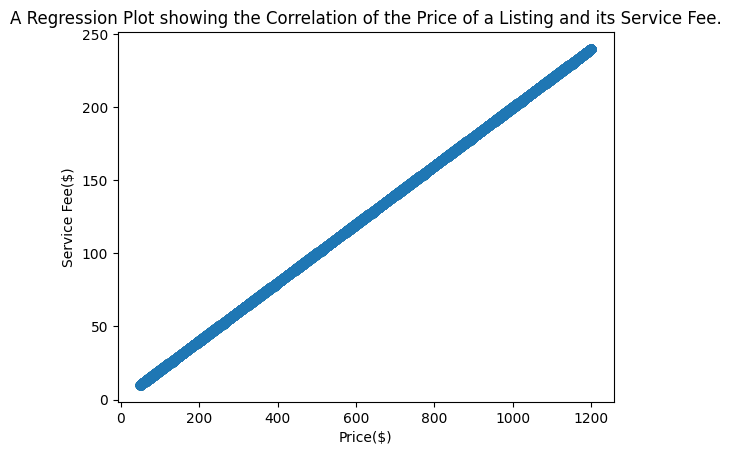

In [28]:
sns.regplot(df, x = 'price_$', y = 'service_fee_$');
plt.xlabel('Price($)');
plt.ylabel('Service Fee($)');
plt.title('A Regression Plot showing the Correlation of the Price of a Listing and its Service Fee.');

In [29]:
# What is the average review rate number (e.g., stars) for listings, and does it vary based on the neighbourhood group and room type?
ARRN = df.groupby(['neighbourhood group','room type'])['review rate number'].mean().to_frame()
ARRN


review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            3.408748
                    Private room               3.381998
                    Shared room                3.350000
Brooklyn            Entire home/apt            3.282984
                    Hotel room                 3.833333
                    Private room               3.322362
                    Shared room                3.347258
Manhattan           Entire home/apt            3.301341
                    Hotel room                 3.500000
                    Private room               3.318473
                    Shared room                3.302174
Queens              Entire home/apt            3.380822
                    Hotel room                 3.750000
                    Private room               3.356418
                    Shared room                3.300000
Staten Island       Entire home/apt            3.355482
                    Private room               3.500000
                    Shared room                3.600000

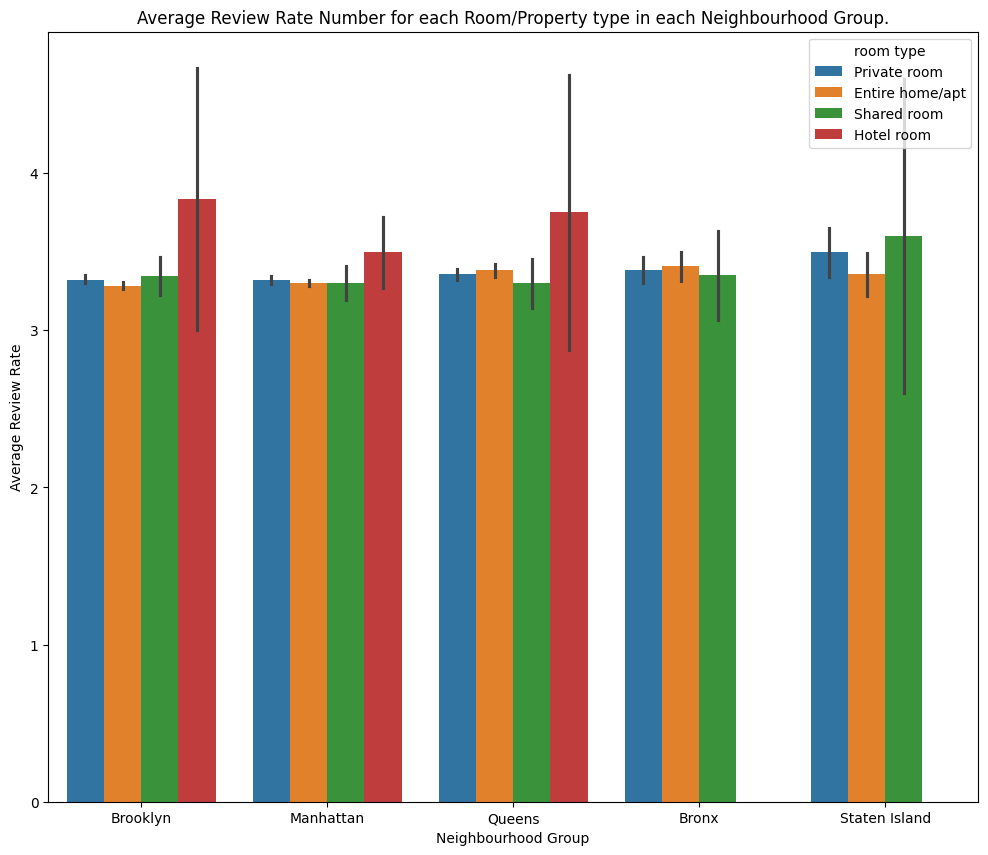

In [30]:
plt.figure(figsize = [12,10]);
sns.barplot(data = df, x = 'neighbourhood group', y = 'review rate number', hue = 'room type');
plt.xlabel('Neighbourhood Group');
plt.ylabel('Average Review Rate');
plt.title('Average Review Rate Number for each Room/Property type in each Neighbourhood Group.');

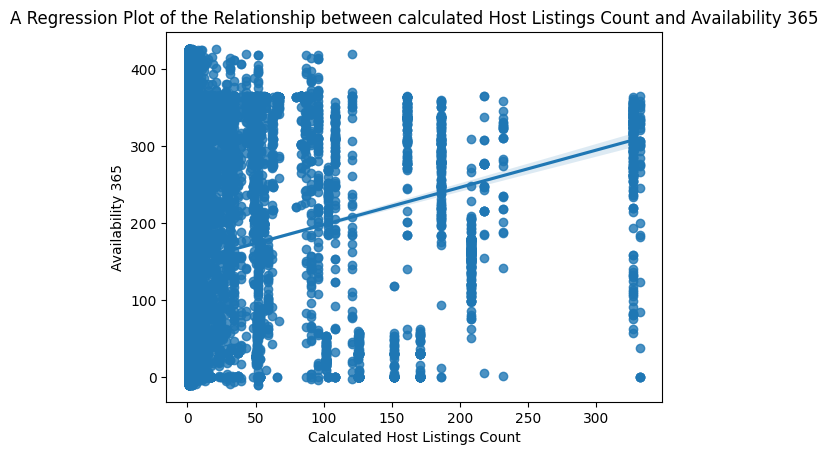

In [31]:
# Are hosts with a higher calculated host listings count more likely to maintain higher availability throughout the year?
sns.regplot(df, x = 'calculated host listings count', y = 'availability 365');
plt.xlabel('Calculated Host Listings Count');
plt.ylabel('Availability 365');
plt.title('A Regression Plot of the Relationship between calculated Host Listings Count and Availability 365');

In [32]:
df['calculated host listings count'].corr(df['availability 365'])

np.float64(0.11287467335562926)